In [1]:
# Importación de librerías base para la ciencia de datos
import pandas as pd  # Manipula, limpia y transforma datos estructurados (tablas/DataFrames)
import seaborn as sns  # Crea gráficos estadísticos avanzados y estéticos con pocas líneas de código
import matplotlib.pyplot as plt  # Controla los detalles del lienzo de dibujo (títulos, etiquetas, ejes)
import numpy as np  # Realiza operaciones matemáticas de alta velocidad y maneja valores numéricos especiales (como NaN)

# %pip: Comando de Jupyter que instala librerías exactamente en el entorno de Python activo
%pip install openpyxl sqlalchemy pandasql

# SQLALCHEMY: Motor que conecta a Python con bases de datos relacionales
from sqlalchemy import engine
# PANDASQL: Permite ejecutar consultas de SQL estándar directamente sobre DataFrames de Pandas
from pandasql import sqldf

# Inyección del entorno global (globals()) para que la función SQL reconozca las tablas de nuestro código
pysqldf = lambda q: sqldf(q, globals())





Note: you may need to restart the kernel to use updated packages.


In [3]:
#2: Ingesta desde Excel y Curación de Tipos de Datos
# pd.read_excel: Carga el archivo nativo de Excel con las nuevas cabeceras de negocio
df = pd.read_excel("Data_financiera.xlsx")

# Tratamiento de strings a flotantes usando la lógica de NUMPY (np.nan) para limpiar caracteres especiales
df['tendencia_corto_plazo'] = df['tendencia_corto_plazo'].astype(str).str.replace('%', '', regex=False).replace('∞', np.nan).astype(float)
df['salud_largo_plazo'] = df['salud_largo_plazo'].astype(str).str.replace('%', '', regex=False).replace('∞', np.nan).astype(float)

# Inspección de las dimensiones de la muestra del mercado ecuatoriano (Filas, Columnas)
print(f"Dataset financiero cargado con éxito. Registros a analizar: {df.shape}")
df.describe()



Dataset financiero cargado con éxito. Registros a analizar: (47, 19)


,volumen_mercado,tendencia_corto_plazo,salud_largo_plazo,indice_competencia,piso_financiero_cpc,techo_financiero_cpc,sep_2025,oct_2025,nov_2025,dic_2025,ene_2026,feb_2026,mar_2026,abr_2026,may_2026,jun_2026
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,620.212766,0.361702,3.021277,25.000000,0.206170,0.930426,682.234043,682.234043,682.234043,682.234043,682.234043,682.234043,682.234043,682.234043,682.234043,682.234043
std,1053.015317,51.563564,43.710754,23.254733,0.152665,0.611000,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849,1158.316849
min,10.000000,-100.000000,-100.000000,0.000000,0.020000,0.200000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
25%,25.000000,-19.000000,-9.500000,1.000000,0.080000,0.500000,27.500000,27.500000,27.500000,27.500000,27.500000,27.500000,27.500000,27.500000,27.500000,27.500000
50%,110.000000,0.000000,0.000000,17.000000,0.150000,0.750000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
75%,880.000000,0.000000,10.500000,42.500000,0.335000,1.200000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000
max,5400.000000,189.000000,150.000000,70.000000,0.550000,3.380000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000,5940.000000


In [6]:
#3: Auditoría de Calidad (Data Cleansing)
# Conteo preventivo de registros duplicados en base a la palabra clave
duplicados = df['entidad'].duplicated().sum()
print(f"Total de registros duplicados detectados: {duplicados}")

# .dropna: Removemos registros nulos en las columnas de pricing para garantizar un análisis financiero exacto
df_clean = df.dropna(subset=['piso_financiero_cpc', 'techo_financiero_cpc']).copy()

print(f"Registros válidos para pauta comercial tras la limpieza: {df_clean.shape}")


Total de registros duplicados detectados: 0
Registros válidos para pauta comercial tras la limpieza: (47, 19)


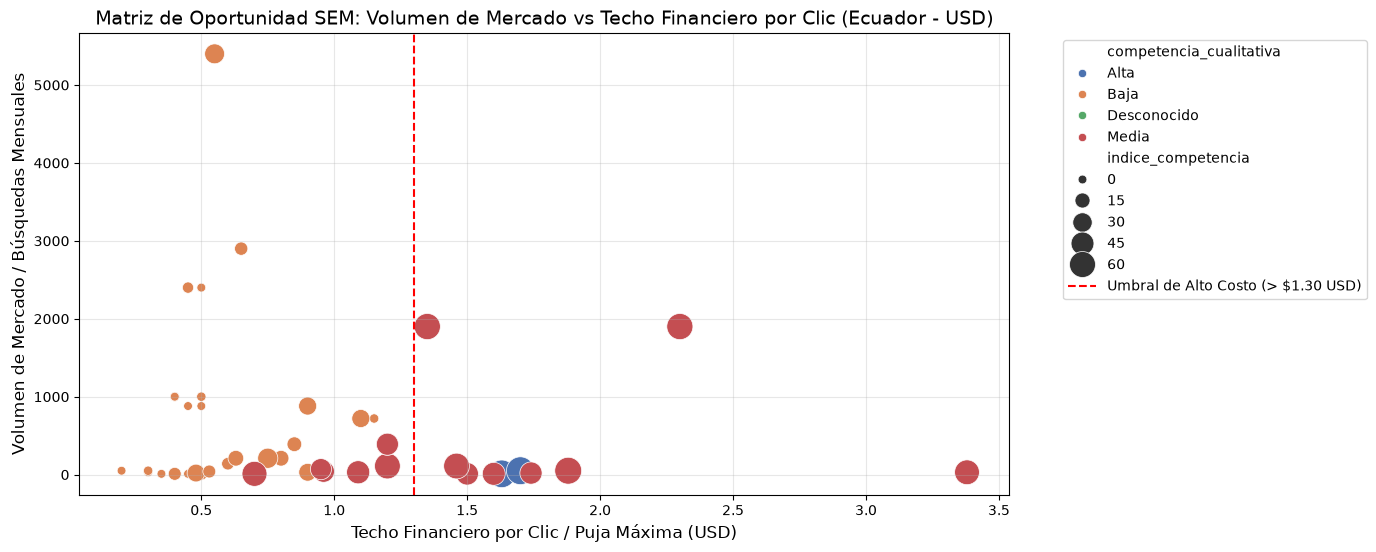

In [7]:
#4: Matriz de Oportunidad SEM (Volumen vs Costo en USD)
plt.figure(figsize=(12, 6))

# Construcción de la matriz cruzando el volumen de mercado contra el techo financiero por clic
sns.scatterplot(
    data=df_clean, 
    x="techo_financiero_cpc", 
    y="volumen_mercado", 
    hue="competencia_cualitativa", 
    size="indice_competencia", 
    sizes=(40, 400),
    palette="deep"
)

# Línea guía de control financiero que delimita la pauta de alto costo por clic
plt.axvline(x=1.30, color='red', linestyle='--', label='Umbral de Alto Costo (> $1.30 USD)')

# Personalización formal y corporativa del lienzo gráfico
plt.title('Matriz de Oportunidad SEM: Volumen de Mercado vs Techo Financiero por Clic (Ecuador - USD)', fontsize=14)
plt.xlabel('Techo Financiero por Clic / Puja Máxima (USD)', fontsize=12)
plt.ylabel('Volumen de Mercado / Búsquedas Mensuales', fontsize=12)

# bbox_to_anchor: Ajuste fino de la leyenda para evitar el TypeError anterior
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.show()





In [9]:
#5: SQL Avanzado - Segmentación por Alta Eficiencia Financiera
# Consulta relacional orientada a extraer términos de bajo costo y alta demanda
q_eficiencia = """
SELECT 
    entidad,
    volumen_mercado,
    competencia_cualitativa,
    techo_financiero_cpc AS cpc_max_usd,
    -- CTR: Estimamos que el 5% de las búsquedas se convertirán en clics reales hacia la web
    ROUND(volumen_mercado * 0.05, 0) AS clics_mensuales_estimados,
    -- MODELADO FINANCIERO: Multiplicamos los clics por el techo financiero para calcular el presupuesto mensual máximo
    ROUND((volumen_mercado * 0.05) * techo_financiero_cpc, 2) AS presupuesto_mensual_max_usd
FROM df_clean
WHERE volumen_mercado >= 200 
  AND techo_financiero_cpc <= 1.30
ORDER BY volumen_mercado DESC;
"""

df_eficiencia = pysqldf(q_eficiencia)
print("=== REPORTING: TÉRMINOS DE ALTA EFICIENCIA FINANCIERA (LOW-CPC / HIGH-VOLUME) ===")
df_eficiencia


=== REPORTING: TÉRMINOS DE ALTA EFICIENCIA FINANCIERA (LOW-CPC / HIGH-VOLUME) ===


,entidad,volumen_mercado,competencia_cualitativa,cpc_max_usd,clics_mensuales_estimados,presupuesto_mensual_max_usd
0,banco pichincha,5400,Baja,0.55,270.0,148.50
1,banco de la produccion,2900,Baja,0.65,145.0,94.25
2,cooperativas de ahorro y crédito seps,2400,Baja,0.45,120.0,54.00
3,sector economico,2400,Baja,0.50,120.0,60.00
4,sectores economicos,2400,Baja,0.50,120.0,60.00
5,cooperativa alianza del valle,1000,Baja,0.40,50.0,20.00
6,sector primario secundario y terciario,1000,Baja,0.40,50.0,20.00
7,sectores de la economia,1000,Baja,0.50,50.0,25.00
8,banco guayaquil,880,Baja,0.90,44.0,39.60
9,sector cuaternario,880,Baja,0.50,44.0,22.00


In [ ]:
#6: SQL Avanzado - Reporte de Riesgo Financiero (Keywords de Alerta)
# Consulta SQL estructurada para detectar las palabras clave sobrevaloradas que atentan contra la rentabilidad
q_riesgo = """
SELECT 
    entidad,
    volumen_mercado,
    competencia_cualitativa,
    techo_financiero_cpc AS cpc_max_usd
FROM df_clean
WHERE techo_financiero_cpc > 1.30
ORDER BY techo_financiero_cpc DESC;
"""

df_riesgo = pysqldf(q_riesgo)
print("=== ALERTA DE CONTROL: TÉRMINOS CON ALTO COSTO DE ADQUISICIÓN (HIGH CPC) ===")
df_riesgo



DatabaseError: Execution failed on sql '
SELECT 
    palabra_clave,
    volumen_mercado,
    competencia_cualitativa,
    techo_financiero_cpc AS cpc_max_usd
FROM df_clean
WHERE techo_financiero_cpc > 1.30
ORDER BY techo_financiero_cpc DESC;
': (sqlite3.OperationalError) no such column: palabra_clave
[SQL: 
SELECT 
    palabra_clave,
    volumen_mercado,
    competencia_cualitativa,
    techo_financiero_cpc AS cpc_max_usd
FROM df_clean
WHERE techo_financiero_cpc > 1.30
ORDER BY techo_financiero_cpc DESC;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)